# Teste de conexão bd



In [6]:
import pandas as pd

df = pd.read_csv("ccmec25a64_main.csv")

print(df.isnull().sum())

co_anomes                     0
co_ibge                       0
vl_indicador_calculado_mun    0
co_uf                         0
no_municipio                  0
sg_uf                         0
no_uf                         0
co_regiao_brasil              0
no_regiao_brasil              0
sg_regiao_brasil              0
co_regiao_saude               0
no_regiao_saude               0
no_macro                      0
co_macro                      0
vl_indicador_calculado_rs     0
vl_indicador_calculado_ms     0
vl_indicador_calculado_uf     0
vl_indicador_calculado_reg    0
vl_indicador_calculado_br     0
vl_indicador_calculado_al     0
dt_competencia                0
dt_atualizacao                0
ds_unidade_medida             0
sg_granularidade              0
ds_granularidade              0
dtype: int64


# outroteste 


In [12]:
import os
print(os.listdir())

['ccmec25a64_main.csv', 'ccmhhcac.csv', 'Notebook1_e_2.ipynb']


# Análise inicial - DATAPREV SUS 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## Etapa de Controle: Verificação e Classificação das Variáveis
Antes de iniciar as limpezas, listamos todas as variáveis da base de dados e as classificamos de acordo com seus tipos estatísticos para controle da equipe.

In [16]:
df = pd.read_csv('ccmec25a64_main.csv')

classificacao_variaveis = {
    "Qualitativas Nominais (Categorias, Nomes, Siglas e IDs sem ordem)": [
        'co_ibge', 'co_uf', 'no_municipio', 'sg_uf', 'no_uf',
        'co_regiao_brasil', 'no_regiao_brasil', 'sg_regiao_brasil',
        'co_regiao_saude', 'no_regiao_saude', 'no_macro', 'co_macro',
        'ds_unidade_medida', 'sg_granularidade', 'ds_granularidade'
    ],
    "Qualitativas Ordinais (Natureza temporal/sequencial)": [
        'co_anomes', 'dt_competencia', 'dt_atualizacao'
    ],
    "Quantitativas Discretas (Valores numéricos de contagem - 'Número')": [
        'vl_indicador_calculado_mun', 'vl_indicador_calculado_rs',
        'vl_indicador_calculado_ms', 'vl_indicador_calculado_uf',
        'vl_indicador_calculado_reg', 'vl_indicador_calculado_br',
        'vl_indicador_calculado_al'
    ]
}

print("="*50)
print(" VERIFICAÇÃO E CLASSIFICAÇÃO DE VARIÁVEIS ".center(50))
print("="*50)

for categoria, colunas in classificacao_variaveis.items():
    print(f"\n{categoria}:")
    for col in colunas:
        if col in df.columns:
            print(f"   - {col}")

print("\n" + "="*50)

     VERIFICAÇÃO E CLASSIFICAÇÃO DE VARIÁVEIS     

Qualitativas Nominais (Categorias, Nomes, Siglas e IDs sem ordem):
   - co_ibge
   - co_uf
   - no_municipio
   - sg_uf
   - no_uf
   - co_regiao_brasil
   - no_regiao_brasil
   - sg_regiao_brasil
   - co_regiao_saude
   - no_regiao_saude
   - no_macro
   - co_macro
   - ds_unidade_medida
   - sg_granularidade
   - ds_granularidade

Qualitativas Ordinais (Natureza temporal/sequencial):
   - co_anomes
   - dt_competencia
   - dt_atualizacao

Quantitativas Discretas (Valores numéricos de contagem - 'Número'):
   - vl_indicador_calculado_mun
   - vl_indicador_calculado_rs
   - vl_indicador_calculado_ms
   - vl_indicador_calculado_uf
   - vl_indicador_calculado_reg
   - vl_indicador_calculado_br
   - vl_indicador_calculado_al



## 1: Limpeza de Dados
Foram aplicadas três limpezas essenciais na base de dados para garantir a consistência das análises estatísticas:

1.  **Conversão de Tipos:** Transformação das colunas de texto para o formato `datetime`.

2.  **Tratamento de Anomalias/Zeros:** Filtragem de registros com valor `0.0`, que indicam ausência de reporte do município e distorcem as médias.

3.  **Remoção de colunas e ordenação:** Exclusão de colunas não utilizadas e ordenação temporal dos registros.

In [32]:

df = pd.read_csv('ccmec25a64_main.csv')

df['dt_competencia'] = pd.to_datetime(df['dt_competencia'])
df['dt_atualizacao'] = pd.to_datetime(df['dt_atualizacao'])


df = df.sort_values(by=['dt_competencia', 'sg_uf', 'no_municipio'])

qtd_zeros = len(df[df['vl_indicador_calculado_mun'] == 0])

print("="*50)
print(f"1. Total de registros na base: {len(df)}")

print("="*50)
print(f"2. Registros municipais com valor zero: {qtd_zeros} ({(qtd_zeros/len(df))*100:.2f}%)")

print("="*50)
df_limpo = df[df['vl_indicador_calculado_mun'] > 0].copy()
print(f"3. Registros válidos (>0) para análise descritiva: {len(df_limpo)}")

print("="*50)
print("4. Valores nulos em colunas:")
print(df.isnull().sum())

print("="*50)
percentual_removido = (qtd_zeros / len(df)) * 100
print(f"5. Percentual removido: {percentual_removido:.2f}%")

print("="*50)
duplicados = df.duplicated().sum()
print(f"6. Registros duplicados: {duplicados}")

df = df.drop_duplicates()

colunas_remover = ['co_ibge', 'co_uf', 'sg_granularidade']
df = df.drop(columns=colunas_remover)

print("="*50)
print(df['vl_indicador_calculado_mun'].describe())

print("#-"*50)
print("COMPARAÇÃO ANTES vs DEPOIS DA LIMPEZA")
print("#-"*50)

antes = len(df)
depois = len(df_limpo)

print(f"Total antes da limpeza: {antes}")
print(f"Total após limpeza: {depois}")
print(f"Registros removidos: {antes - depois}")
print(f"Percentual removido: {((antes - depois)/antes)*100:.2f}%")

print("-"*50)
print("IMPACTO DOS ZEROS NAS ESTATÍSTICAS")
print("-"*50)

media_antes = df['vl_indicador_calculado_mun'].mean()
media_depois = df_limpo['vl_indicador_calculado_mun'].mean()

print(f"Média antes da limpeza: {media_antes:.2f}")
print(f"Média após limpeza: {media_depois:.2f}")

print("-"*50)
print("Distribuição de valores zero vs válidos")
print("-"*50)

print(f"Zeros: {qtd_zeros}")
print(f"Válidos: {len(df_limpo)}")

print("-"*50)
print("VALIDAÇÃO FINAL DO DATASET")
print("-"*50)

print("Valores nulos após limpeza:")
print(df_limpo.isnull().sum().to_string())

print("\nDuplicados após limpeza:")
print(df_limpo.duplicated().sum())

1. Total de registros na base: 55702
2. Registros municipais com valor zero: 49716 (89.25%)
3. Registros válidos (>0) para análise descritiva: 5986
4. Valores nulos em colunas:
co_anomes                     0
co_ibge                       0
vl_indicador_calculado_mun    0
co_uf                         0
no_municipio                  0
sg_uf                         0
no_uf                         0
co_regiao_brasil              0
no_regiao_brasil              0
sg_regiao_brasil              0
co_regiao_saude               0
no_regiao_saude               0
no_macro                      0
co_macro                      0
vl_indicador_calculado_rs     0
vl_indicador_calculado_ms     0
vl_indicador_calculado_uf     0
vl_indicador_calculado_reg    0
vl_indicador_calculado_br     0
vl_indicador_calculado_al     0
dt_competencia                0
dt_atualizacao                0
ds_unidade_medida             0
sg_granularidade              0
ds_granularidade              0
dtype: int64
5. Percent

## 2. Análise Inferencial e Comparativa
Vamos visualizar a distribuição dos dados para identificar *outliers* (municípios que fogem do padrão) e entender a disparidade entre os estados.


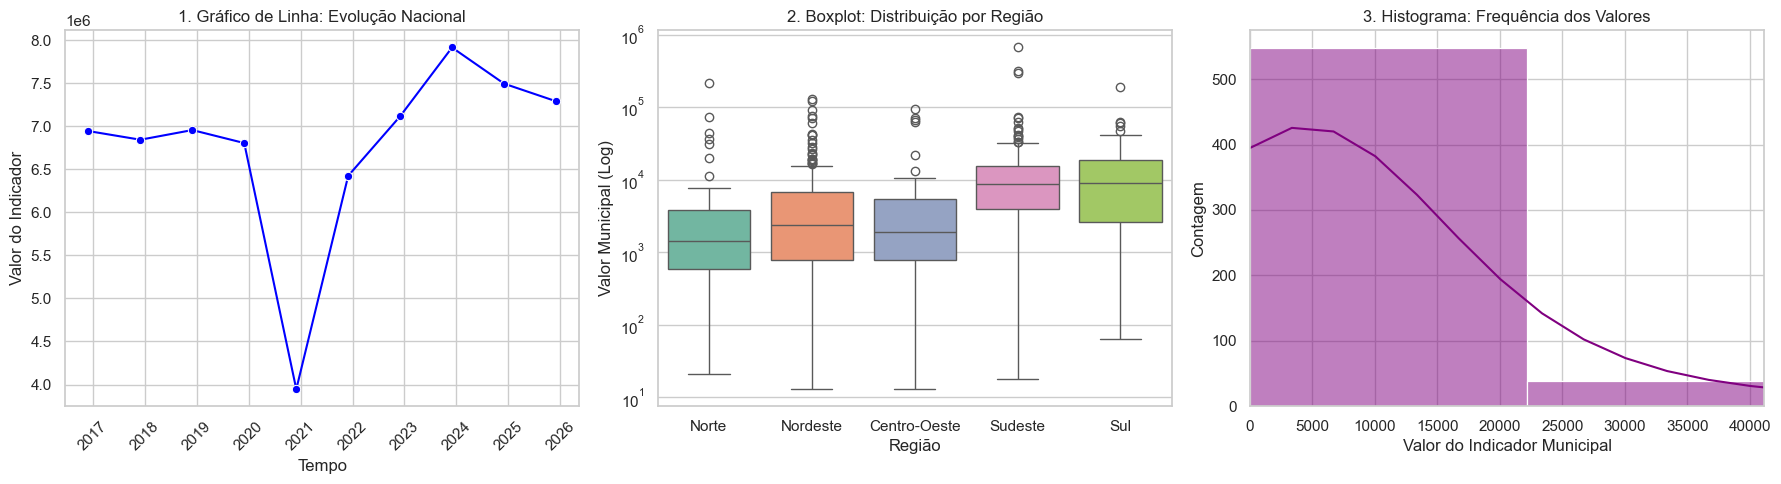

In [ ]:
df_recente = df_limpo[df_limpo['dt_competencia'] == df_limpo['dt_competencia'].max()]
df_tempo = df.groupby('dt_competencia')['vl_indicador_calculado_br'].mean().reset_index()

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.lineplot(data=df_tempo, x='dt_competencia', y='vl_indicador_calculado_br', marker='o', color='blue')
plt.title('1. Gráfico de Linha: Evolução Nacional')
plt.xlabel('Tempo')
plt.ylabel('Valor do Indicador')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(data=df_recente, x='no_regiao_brasil', y='vl_indicador_calculado_mun', palette='Set2')
plt.title('2. Boxplot: Distribuição por Região')
plt.xlabel('Região')
plt.ylabel('Valor Municipal (Log)')
plt.yscale('log') 

plt.subplot(1, 3, 3)
sns.histplot(df_recente['vl_indicador_calculado_mun'], bins=30, kde=True, color='purple')
plt.title('3. Histograma: Frequência dos Valores')
plt.xlabel('Valor do Indicador Municipal')
plt.ylabel('Contagem')
plt.xlim(0, df_recente['vl_indicador_calculado_mun'].quantile(0.95)) 

plt.tight_layout()
plt.show()


## 3. Modelagem Preditiva e Visualização (Responsável: Lucas)
Utilizando Regressão Linear Simples, vamos projetar a tendência do indicador consolidado no Brasil para os próximos 6 meses.

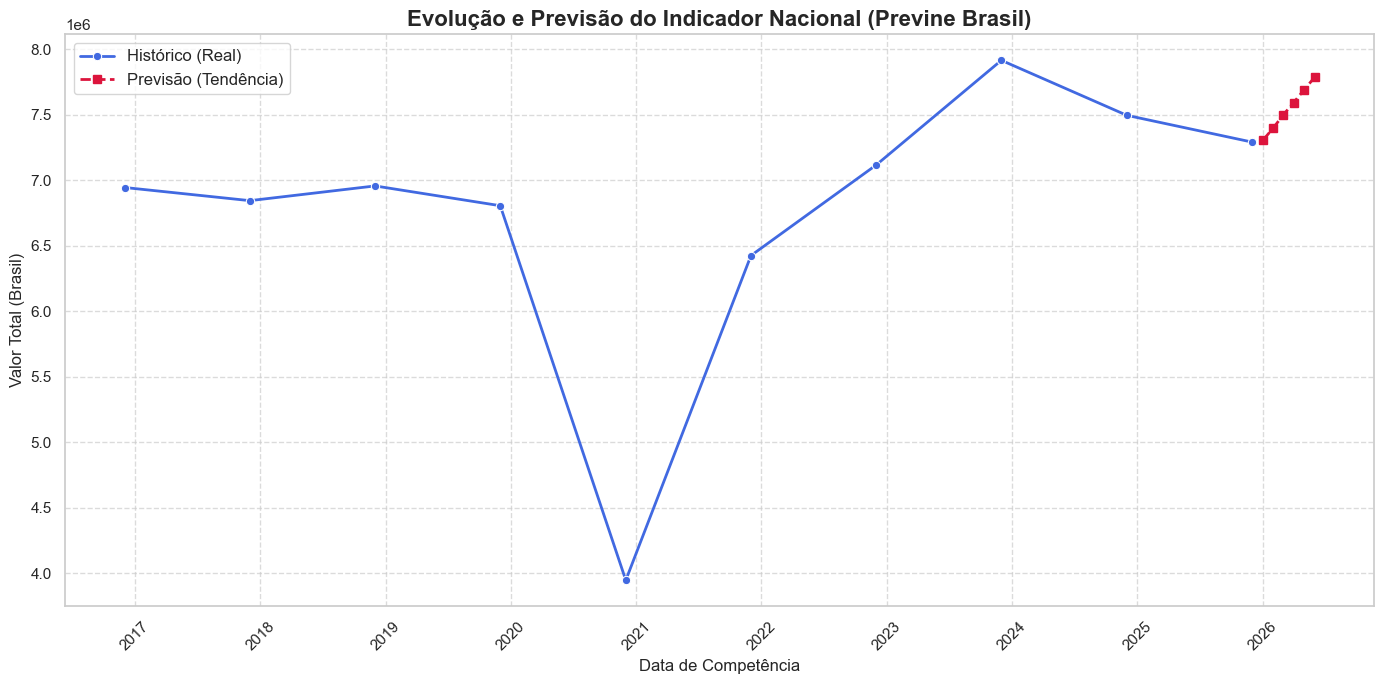


--- Projeção para os Próximos 6 Meses ---


,Data Prevista,Valor Projetado
0,01/2026,7303832.0
1,02/2026,7400131.0
2,03/2026,7496431.0
3,04/2026,7592730.0
4,05/2026,7689030.0
5,06/2026,7785329.0


In [ ]:
# 4.1 Preparar dados para o modelo
# Usar a base completa - Os zeros influênciam no calculo geral - (high mean) / (low mean)
df_trend = df.groupby('dt_competencia')['vl_indicador_calculado_br'].mean().reset_index()
df_trend = df_trend.sort_values('dt_competencia')
df_trend['mes_idx'] = range(len(df_trend))

X = df_trend[['mes_idx']]
y = df_trend['vl_indicador_calculado_br']

modelo = LinearRegression()
modelo.fit(X, y)

meses_futuros = 6
ultimo_idx = df_trend['mes_idx'].max()
X_futuro = np.array(range(ultimo_idx + 1, ultimo_idx + 1 + meses_futuros)).reshape(-1, 1)
y_pred = modelo.predict(X_futuro)

#Datas futura e previstas com base na análise
ultima_data_historico = df_trend['dt_competencia'].max()
datas_futuras = [ultima_data_historico + pd.DateOffset(months=i) for i in range(1, meses_futuros + 1)]


#Histórico e Previsão
plt.figure(figsize=(14, 7))

# Linha Histórica
sns.lineplot(data=df_trend, x='dt_competencia', y='vl_indicador_calculado_br', 
             marker='o', color='royalblue', label='Histórico (Real)', linewidth=2)

# Linha de Previsão
plt.plot(datas_futuras, y_pred, marker='s', color='crimson', 
         linestyle='--', label='Previsão (Tendência)', linewidth=2)

plt.title('Evolução e Previsão do Indicador Nacional (Previne Brasil)', fontsize=16, fontweight='bold')
plt.xlabel('Data de Competência', fontsize=12)
plt.ylabel('Valor Total (Brasil)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4.5 Exibir tabela de previsões
previsoes_df = pd.DataFrame({
    'Data Prevista': [d.strftime('%m/%Y') for d in datas_futuras],
    'Valor Projetado': np.round(y_pred, 0)
})
print("\n--- Projeção para os Próximos 6 Meses ---")
display(previsoes_df)